<a href="https://colab.research.google.com/github/2303a51019/Data-Analaysis/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, brier_score_loss, log_loss

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true_labels, y_pred_labels)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# Cohen's Kappa Score
kappa = cohen_kappa_score(y_true_labels, y_pred_labels)
print(f"Cohen's Kappa Score: {kappa:.4f}")

Matthews Correlation Coefficient (MCC): 0.6528
Cohen's Kappa Score: 0.6522


### Brier Score

The Brier score measures the accuracy of probabilistic predictions. For multi-class classification, it's often calculated as the mean squared difference between the actual outcomes and the predicted probabilities.

In [ ]:
# Brier Score (multi-class: average across classes)
# For multi-class, we can calculate it for each class or overall
brier_scores = []
for i in range(num_classes):
    score = brier_score_loss(y_test_one_hot[:, i], y_pred_proba[:, i])
    brier_scores.append(score)

mean_brier_score = np.mean(brier_scores)

print("Brier Score per class:")
for i, score in enumerate(brier_scores):
    print(f"  {class_names[i]}: {score:.4f}")
print(f"Mean Brier Score: {mean_brier_score:.4f}")

Brier Score per class:
  airplane: 0.0395
  automobile: 0.0287
  bird: 0.0583
  cat: 0.0639
  deer: 0.0513
  dog: 0.0536
  frog: 0.0382
  horse: 0.0376
  ship: 0.0291
  truck: 0.0321
Mean Brier Score: 0.0432


### Log Loss (Cross-Entropy Loss)

Log Loss quantifies the performance of a classification model where the prediction is a probability value between 0 and 1. It measures the uncertainty of the predictions based on how much they vary from the actual labels. A perfect model would have a Log Loss of 0.

### Jaccard Index (Intersection over Union)

The Jaccard Index, also known as Intersection over Union (IoU), measures the similarity and diversity of sample sets. It is defined as the size of the intersection divided by the size of the union of the sample sets. In classification, it can be used to compare the predicted class with the true class, often calculated per class in a one-vs-rest approach for multi-class problems. A higher Jaccard Index indicates greater similarity between the predicted and true labels.

In [ ]:
from sklearn.metrics import jaccard_score

# Calculate Jaccard Index for each class (one-vs-rest)
jaccard_scores = []
for i in range(num_classes):
    # Convert true and predicted labels to binary for the current class
    y_true_binary = (y_true_labels == i).astype(int)
    y_pred_binary = (y_pred_labels == i).astype(int)
    score = jaccard_score(y_true_binary, y_pred_binary)
    jaccard_scores.append(score)

print("Jaccard Index per class:")
for i, score in enumerate(jaccard_scores):
    print(f"  {class_names[i]}: {score:.4f}")

macro_jaccard_score = np.mean(jaccard_scores)
print(f"\nMacro Average Jaccard Index: {macro_jaccard_score:.4f}")

Jaccard Index per class:
  airplane: 0.5673
  automobile: 0.6780
  bird: 0.3796
  cat: 0.3526
  deer: 0.4411
  dog: 0.4194
  frog: 0.5823
  horse: 0.5816
  ship: 0.6748
  truck: 0.6303

Macro Average Jaccard Index: 0.5307


### G-mean (Geometric Mean)

In binary classification, G-mean is the geometric mean of sensitivity (recall) and specificity. It is particularly useful for imbalanced datasets as it tries to maximize the accuracy on each of the classes while keeping the accuracies on different classes balanced. For multi-class classification, it can be calculated per class in a one-vs-rest manner and then averaged.

In [ ]:
# Calculate G-mean for each class
g_means = []

for i in range(num_classes):
    # True Positives
    tp = cm[i, i]
    # False Negatives
    fn = cm[i, :].sum() - tp
    # False Positives
    fp = cm[:, i].sum() - tp
    # True Negatives (already calculated in specificity, but re-calculating for clarity)
    tn = cm.sum() - (tp + fn + fp)

    # Sensitivity (Recall) for class i
    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
    # Specificity for class i
    specificity_val = tn / (tn + fp) if (tn + fp) != 0 else 0

    # G-mean
    g_mean_val = np.sqrt(sensitivity * specificity_val)
    g_means.append(g_mean_val)

print("G-mean per class:")
for i, gm in enumerate(g_means):
    print(f"  {class_names[i]}: {gm:.4f}")

mean_g_mean = np.mean(g_means)
print(f"\nMean G-mean: {mean_g_mean:.4f}")

G-mean per class:
  airplane: 0.8504
  automobile: 0.8835
  bird: 0.7061
  cat: 0.7182
  deer: 0.7443
  dog: 0.7309
  frog: 0.8994
  horse: 0.8337
  ship: 0.8847
  truck: 0.8627

Mean G-mean: 0.8114


### KS Statistic (Kolmogorov-Smirnov Statistic)

The Kolmogorov-Smirnov (KS) statistic is primarily used in **binary classification** to measure the maximum difference between the cumulative true positive rate and the cumulative false positive rate across all possible classification thresholds. It quantifies the separation between the positive and negative distributions, indicating how well a model discriminates between the two classes.

While it's a powerful metric for binary classifiers (especially in credit scoring or fraud detection), its direct application to multi-class problems is less common and more complex. It would typically involve calculating the KS statistic for each class in a one-vs-rest setting, which might not provide a single, easily interpretable overall metric like accuracy or F1-score for multi-class scenarios. Given the existing comprehensive set of multi-class metrics (like precision, recall, F1-score, ROC/AUC, Brier score, Log Loss, MCC, Cohen's Kappa, and Specificity), the KS statistic is generally not a primary evaluation metric for standard multi-class image classification tasks.

### Lift Chart

A Lift Chart is a visual representation of the effectiveness of a classification model compared to a random selection. It shows how much more likely you are to receive a positive response (or identify a positive case) using the model, compared to if you contacted a random sample of the same size. For instance, if a lift of 3 at the 10% decile means that by targeting the top 10% of cases identified by the model, you'll find 3 times as many positive cases as you would by randomly selecting 10% of the population.

In a multi-class setting, we typically generate a lift chart for each class in a "one-vs-rest" approach, treating one class as the positive and all others as negative.

### Gain Chart

A Gain Chart (or Response Chart) is closely related to the lift chart. It plots the cumulative percentage of positive responses identified by the model against the cumulative percentage of the population considered. It directly shows what percentage of all positive cases your model has identified by a certain decile of the population. For example, a point at (20%, 70%) on a gain chart means that by targeting the top 20% of your population (as ranked by the model's probability scores), you can capture 70% of all the positive instances.

Like the lift chart, it's typically applied one-vs-rest for multi-class problems.

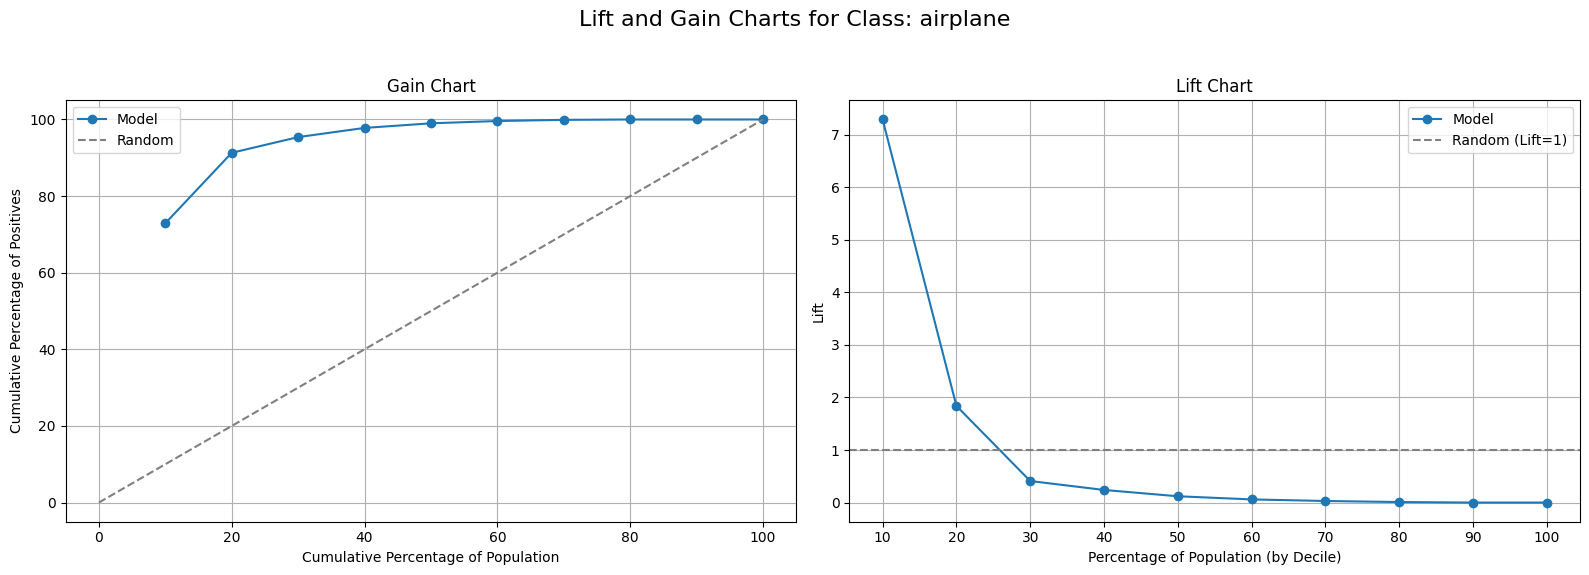

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_gain_charts(y_true_binary, y_proba, class_name, n_bins=10):
    df = pd.DataFrame({'true': y_true_binary, 'proba': y_proba})
    df = df.sort_values(by='proba', ascending=False).reset_index(drop=True)

    total_positives = df['true'].sum()
    total_population = len(df)
    overall_positive_rate = total_positives / total_population

    # Initialize lists for plotting
    population_percent = []
    cumulative_positives_percent = []
    lift_values = []

    for i in range(1, n_bins + 1):
        subset_size = int(total_population * (i / n_bins))
        subset = df.head(subset_size)

        current_population_percent = (subset_size / total_population) * 100
        current_cumulative_positives = subset['true'].sum()
        current_cumulative_positives_percent = (current_cumulative_positives / total_positives) * 100 if total_positives > 0 else 0

        population_percent.append(current_population_percent)
        cumulative_positives_percent.append(current_cumulative_positives_percent)

        # Calculate lift for the current decile (not cumulative)
        if i == 1:
            decile_subset = subset
        else:
            decile_subset = df.head(subset_size).tail(int(total_population / n_bins))

        decile_positives = decile_subset['true'].sum()
        decile_population = len(decile_subset)

        if decile_population > 0 and overall_positive_rate > 0:
            decile_response_rate = decile_positives / decile_population
            lift = decile_response_rate / overall_positive_rate
            lift_values.append(lift)
        else:
            lift_values.append(0)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Lift and Gain Charts for Class: {class_name}', fontsize=16)

    # Gain Chart
    axes[0].plot(population_percent, cumulative_positives_percent, marker='o', label='Model')
    axes[0].plot([0, 100], [0, 100], linestyle='--', color='gray', label='Random')
    axes[0].set_title('Gain Chart')
    axes[0].set_xlabel('Cumulative Percentage of Population')
    axes[0].set_ylabel('Cumulative Percentage of Positives')
    axes[0].grid(True)
    axes[0].legend()

    # Lift Chart
    axes[1].plot([(i + 1) * (100/n_bins) for i in range(n_bins)], lift_values, marker='o', label='Model')
    axes[1].axhline(y=1, color='gray', linestyle='--', label='Random (Lift=1)')
    axes[1].set_title('Lift Chart')
    axes[1].set_xlabel('Percentage of Population (by Decile)')
    axes[1].set_ylabel('Lift')
    axes[1].grid(True)
    axes[1].legend()
    axes[1].set_xticks([(i + 1) * (100/n_bins) for i in range(n_bins)])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example: Plot for 'airplane' (class index 0)
class_index = 0
class_name_to_plot = class_names[class_index]

y_true_binary_selected = y_test_one_hot[:, class_index]
y_proba_selected = y_pred_proba[:, class_index]

plot_lift_gain_charts(y_true_binary_selected, y_proba_selected, class_name_to_plot)

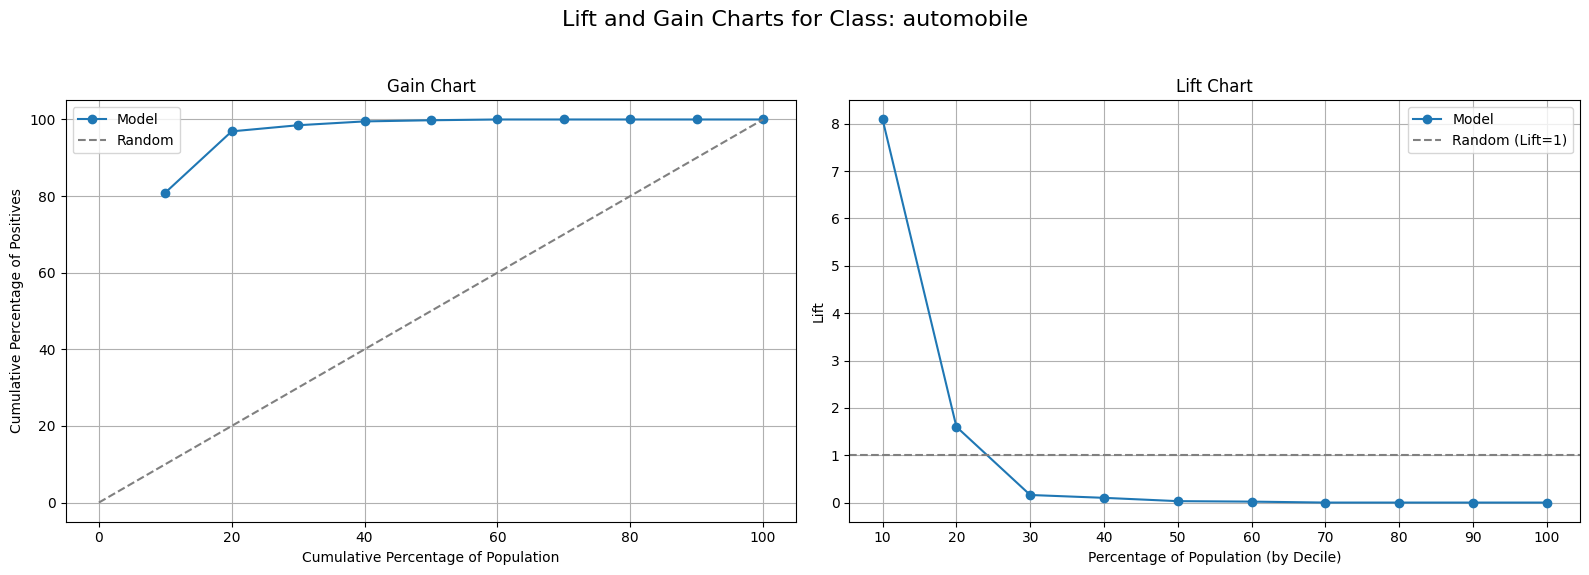

In [ ]:
# Example: Plot for 'automobile' (class index 1)
class_index = 1
class_name_to_plot = class_names[class_index]

y_true_binary_selected = y_test_one_hot[:, class_index]
y_proba_selected = y_pred_proba[:, class_index]

plot_lift_gain_charts(y_true_binary_selected, y_proba_selected, class_name_to_plot)

### Calibration Curve (Reliability Diagram)

A calibration curve (also known as a reliability diagram) plots the predicted probability against the true probability of an event. It helps to assess how well the predicted probabilities of a classification model are calibrated. A perfectly calibrated model would have its predictions lie on the diagonal line. For multi-class classification, we typically generate one curve per class using a one-vs-rest approach.

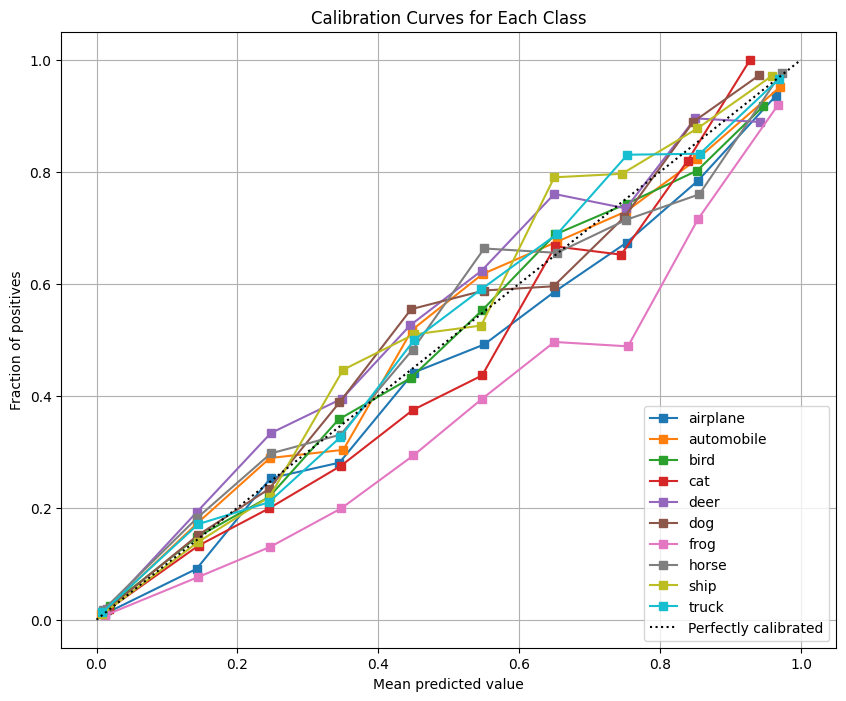

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    # Extract true labels and predicted probabilities for the current class (one-vs-rest)
    y_true_class = y_test_one_hot[:, i]
    y_proba_class = y_pred_proba[:, i]

    # Calculate calibration curve data
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true_class, y_proba_class, n_bins=10)

    # Plot the calibration curve for the current class
    plt.plot(mean_predicted_value, fraction_of_positives, "s-",
             label=f"{class_names[i]}")

plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curves for Each Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Log Loss
logloss = log_loss(y_test_one_hot, y_pred_proba)
print(f"Log Loss: {logloss:.4f}")

Log Loss: 0.9146


To ensure CUDA (GPU) is being utilized by TensorFlow, you can check for available GPUs:

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions (probabilities) for the test set
y_pred_proba = model.predict(x_test_normalized)

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred_proba, axis=1)

# Get true class labels from one-hot encoded labels
y_true_labels = np.argmax(y_test_one_hot, axis=1)

print("Predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions generated successfully!


### Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

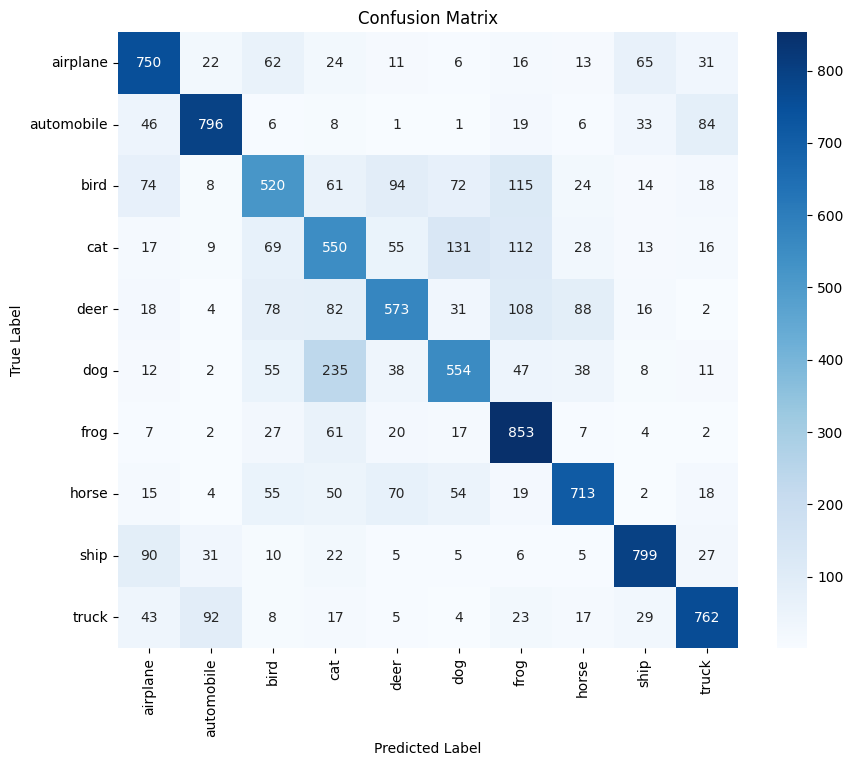

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Classification Report (Accuracy, Precision, Recall, F1-Score)

The classification report provides a comprehensive summary of precision, recall, F1-score, and support for each class. Accuracy is also derived from these metrics.

In [ ]:
# Print the classification report
print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

    airplane       0.70      0.75      0.72      1000
  automobile       0.82      0.80      0.81      1000
        bird       0.58      0.52      0.55      1000
         cat       0.50      0.55      0.52      1000
        deer       0.66      0.57      0.61      1000
         dog       0.63      0.55      0.59      1000
        frog       0.65      0.85      0.74      1000
       horse       0.76      0.71      0.74      1000
        ship       0.81      0.80      0.81      1000
       truck       0.78      0.76      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



### Specificity

Specificity measures the proportion of actual negatives that are correctly identified as such. In a multi-class context, it's often calculated per class (true negatives for a class divided by the sum of true negatives and false positives for that class).

In [ ]:
# Calculate specificity for each class
num_classes = len(class_names)
specificity = []

for i in range(num_classes):
    # True Negatives: sum of all cells not in the i-th row or i-th column
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    # False Positives: sum of the i-th column excluding the i-th row
    fp = cm[:, i].sum() - cm[i, i]

    # Handle division by zero for cases where TN + FP is 0
    if (tn + fp) == 0:
        specificity_score = np.nan # Or 0, depending on interpretation
    else:
        specificity_score = tn / (tn + fp)
    specificity.append(specificity_score)

print("Specificity per class:")
for i, spec in enumerate(specificity):
    print(f"  {class_names[i]}: {spec:.4f}")

Specificity per class:
  airplane: 0.9642
  automobile: 0.9807
  bird: 0.9589
  cat: 0.9378
  deer: 0.9668
  dog: 0.9643
  frog: 0.9483
  horse: 0.9749
  ship: 0.9796
  truck: 0.9768


### ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is the measure of the ability of a classifier to distinguish between classes and is used as a summary of the ROC curve.

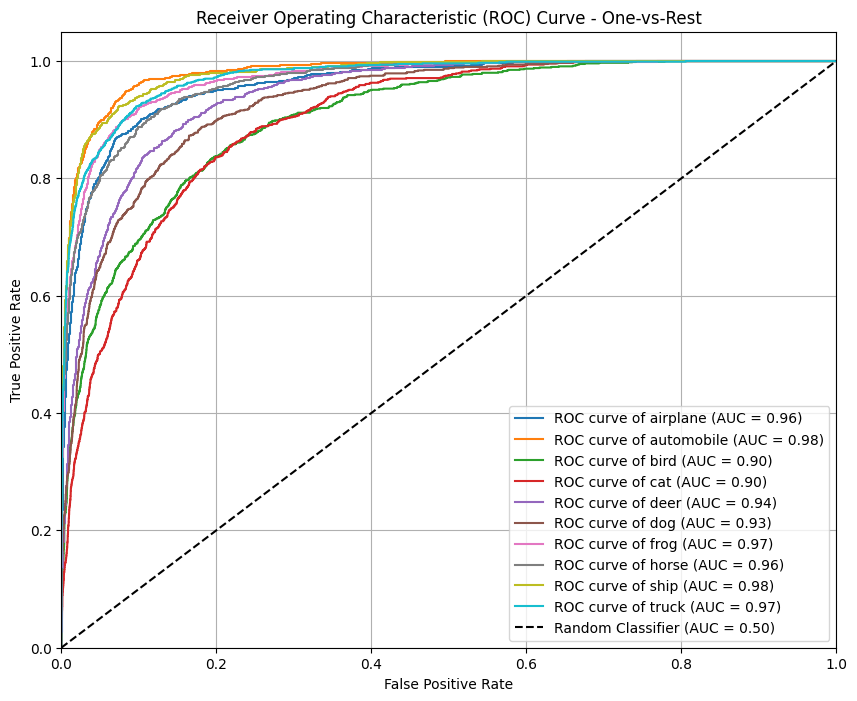

In [ ]:
# Plot ROC curves for each class (One-vs-Rest)
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
history = model.fit(x_train_normalized, y_train_one_hot, epochs=5,
                    validation_data=(x_test_normalized, y_test_one_hot))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4440 - loss: 1.5230 - val_accuracy: 0.4895 - val_loss: 1.4548
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5818 - loss: 1.1784 - val_accuracy: 0.5984 - val_loss: 1.1357
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6332 - loss: 1.0430 - val_accuracy: 0.6391 - val_loss: 1.0257
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6674 - loss: 0.9461 - val_accuracy: 0.6523 - val_loss: 0.9964
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6928 - loss: 0.8745 - val_accuracy: 0.6870 - val_loss: 0.9146


In [ ]:
test_loss, test_acc = model.evaluate(x_test_normalized, y_test_one_hot, verbose=2)
print(f"\nTest Accuracy: {test_acc}")
print(f"Test Loss: {test_loss}")

313/313 - 1s - 2ms/step - accuracy: 0.6870 - loss: 0.9146

Test Accuracy: 0.6869999766349792
Test Loss: 0.9146265387535095


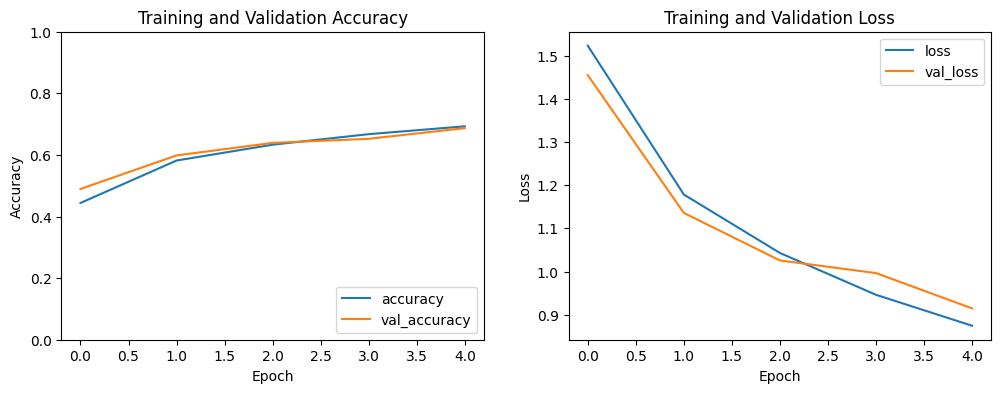

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax') # Output layer with number of classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"x_train_normalized shape: {x_train_normalized.shape}, min: {x_train_normalized.min()}, max: {x_train_normalized.max()}")
print(f"x_test_normalized shape: {x_test_normalized.shape}, min: {x_test_normalized.min()}, max: {x_test_normalized.max()}")

x_train_normalized shape: (50000, 32, 32, 3), min: 0.0, max: 1.0
x_test_normalized shape: (10000, 32, 32, 3), min: 0.0, max: 1.0


In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=len(class_names))
y_test_one_hot = to_categorical(y_test, num_classes=len(class_names))

print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

y_train_one_hot shape: (50000, 10)
y_test_one_hot shape: (10000, 10)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

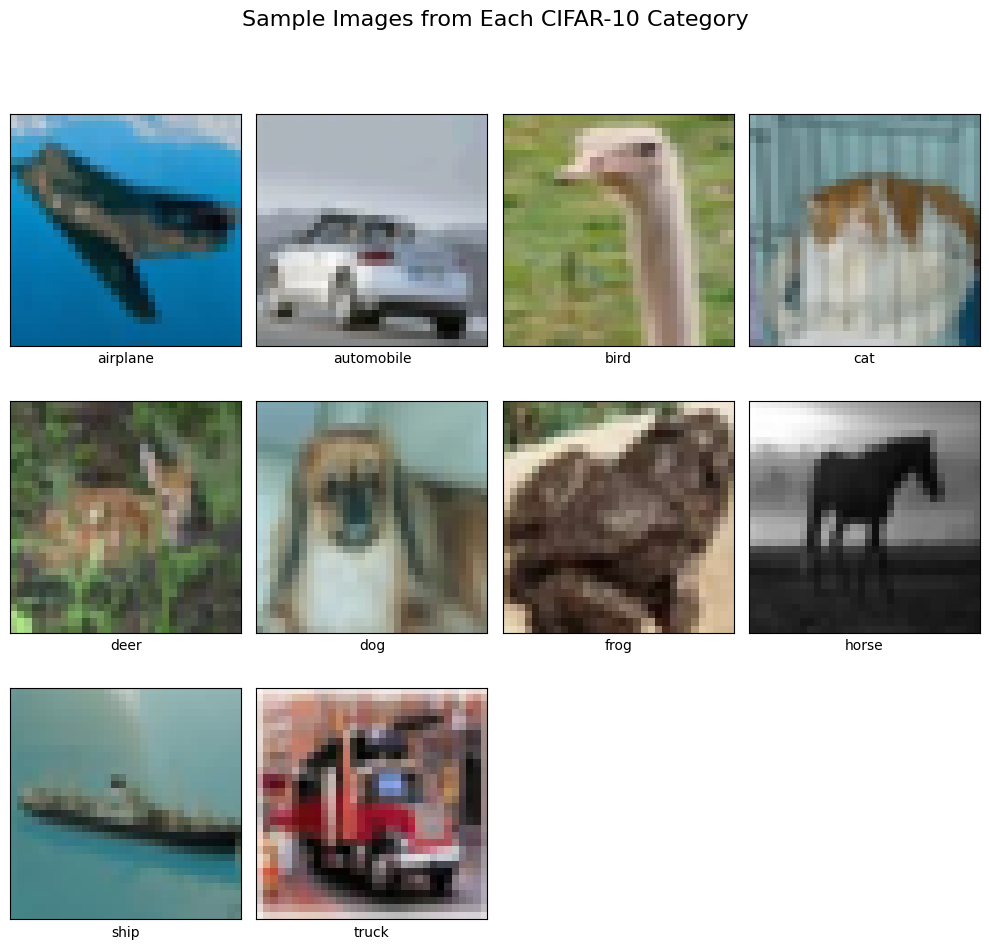

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(len(class_names)):
    # Get all indices for the current class
    idx = np.where(y_train == i)[0]
    # Pick a random image from this class
    sample_idx = np.random.choice(idx)

    plt.subplot(3, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[sample_idx])
    plt.xlabel(class_names[i])
plt.suptitle('Sample Images from Each CIFAR-10 Category', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA support.")
else:
    print("TensorFlow is NOT built with CUDA support.")

if tf.config.list_physical_devices('GPU'):
    print("GPU is available and detected by TensorFlow.")
else:
    print("No GPU detected by TensorFlow. Running on CPU.")

Num GPUs Available:  1
TensorFlow is built with CUDA support.
GPU is available and detected by TensorFlow.
